In [1]:
import pandas as pd
db = pd.read_csv('data/tidy_data.csv', sep=";", decimal=",", index_col=0)
print(db)

      indicator code  estimate    stddev  nsource   pctrank  pctranklower  \
1            cc  AGO -0.012749 -0.035021        4 -2.190789     -0.537634   
2            cc  AGO -0.017064  0.023130        4  1.024007      0.000000   
3            cc  AGO  0.042022 -0.037853        4 -0.574131      0.000000   
4            cc  AGO -0.179971 -0.021847        6 -2.645503      0.000000   
5            cc  AGO -0.042106 -0.005851        8  0.620325      0.000000   
...         ...  ...       ...       ...      ...       ...           ...   
17485        va  ZWE  0.009821  0.001722       17 -0.109369      3.791469   
17486        va  ZWE  0.064029 -0.001421       17  0.473934      5.687204   
17487        va  ZWE  0.011419  0.000566       18 -0.075652      5.164319   
17488        va  ZWE -0.008206 -0.003048       19 -0.469484      3.755868   
17489        va  ZWE  0.085636 -0.003878       19  2.347418      5.164319   

       pctrankupper      eiu       prs     wmo  scalemean   scalesd  \
1   

In [2]:
import numpy as np

db['indicator'] = db['indicator'].astype('category')
db['code'] = db['code'].astype('category')
db['extreme_event'] = db['extreme_event'].astype('category')
grouped = db.groupby(['indicator', 'code'], observed=False)
db['estimate'] = grouped['estimate'].transform(lambda x: (x - x.mean()) / x.std())
db['stddev'] = grouped['stddev'].transform(lambda x: (x - x.mean()) / x.std())
db['pctrank'] = grouped['pctrank'].transform(lambda x: (x - x.mean()) / x.std())
db['pctranklower'] = grouped['pctranklower'].transform(lambda x: (x - x.mean()) / x.std())
db['pctrankupper'] = grouped['pctrankupper'].transform(lambda x: (x - x.mean()) / x.std())
db['eiu'] = grouped['eiu'].transform(lambda x: (x - x.mean()) / x.std())
db['prs'] = grouped['prs'].transform(lambda x: (x - x.mean()) / x.std())
db['wmo'] = grouped['wmo'].transform(lambda x: (x - x.mean()) / x.std())
db['scalemean'] = grouped['scalemean'].transform(lambda x: (x - x.mean()) / x.std())
db['scalesd'] = grouped['scalesd'].transform(lambda x: (x - x.mean()) / x.std())

db = db.replace([np.inf, -np.inf], np.nan)
db = db.dropna()

print(db)

      indicator code  estimate    stddev  nsource   pctrank  pctranklower  \
25           ge  AGO  0.387650  0.656218        3  0.826667     -0.285729   
26           ge  AGO  0.222203  1.620900        3 -0.211623     -0.752155   
27           ge  AGO -0.252066 -0.713279        4 -0.833796     -0.536591   
28           ge  AGO -0.186203 -1.263063        5 -0.100178     -0.997973   
29           ge  AGO -1.885316 -1.054981        6 -2.124380     -1.726774   
...         ...  ...       ...       ...      ...       ...           ...   
17485        va  ZWE  0.501442  0.743286       17  0.415545     -0.544465   
17486        va  ZWE  0.918585  0.489832       17  0.593123      0.096843   
17487        va  ZWE  0.513741  0.650102       18  0.425810     -0.080043   
17488        va  ZWE  0.362724  0.358691       19  0.305914     -0.556508   
17489        va  ZWE  1.084859  0.291755       19  1.163475     -0.080043   

       pctrankupper       eiu       prs       wmo  scalemean   scalesd  \
2

| ('variable', '')   |   ('correlation', 'shift_0') |   ('correlation', 'shift_1') |   ('correlation', 'shift_2') |   ('p_value', 'shift_0') |   ('p_value', 'shift_1') |   ('p_value', 'shift_2') | ('Conclusão shift_0', '')   | ('Conclusão shift_1', '')   | ('Conclusão shift_2', '')   |
|:-------------------|-----------------------------:|-----------------------------:|-----------------------------:|-------------------------:|-------------------------:|-------------------------:|:----------------------------|:----------------------------|:----------------------------|
| eiu                |                  0.0165625   |                   0.00708322 |                   0.00562365 |              0.0502481   |              0.40245     |              0.506225    | Não Significativo           | Não Significativo           | Não Significativo           |
| estimate           |                 -0.0187381   |                  -0.00105964 |                  -0.00788563 |              0.0267559 

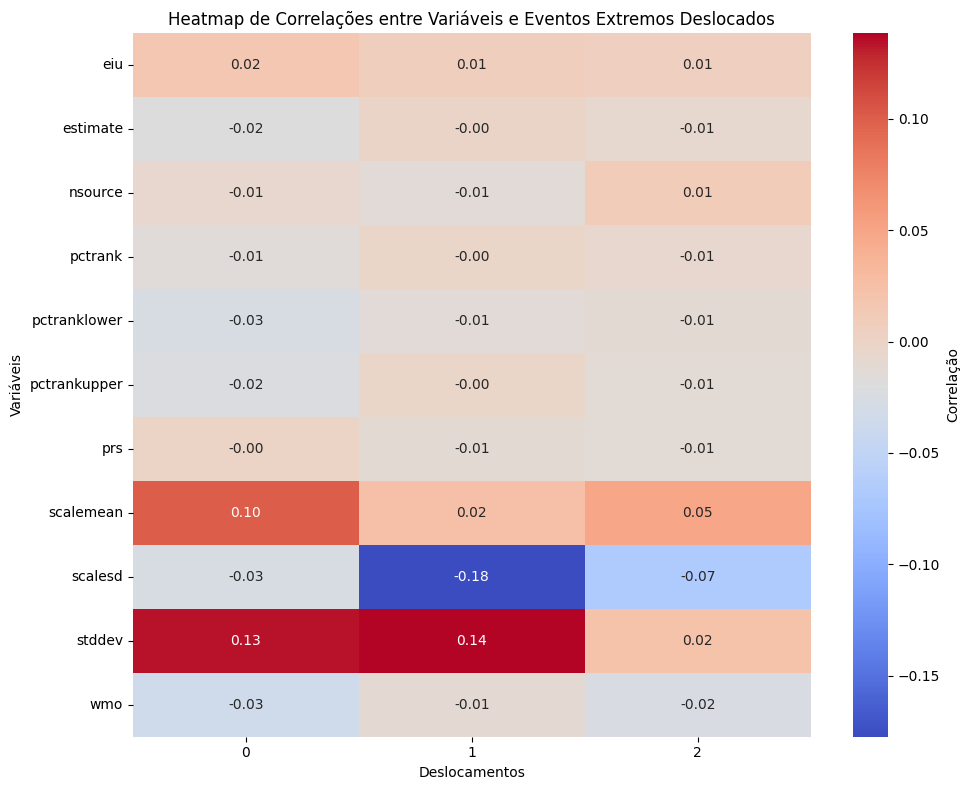

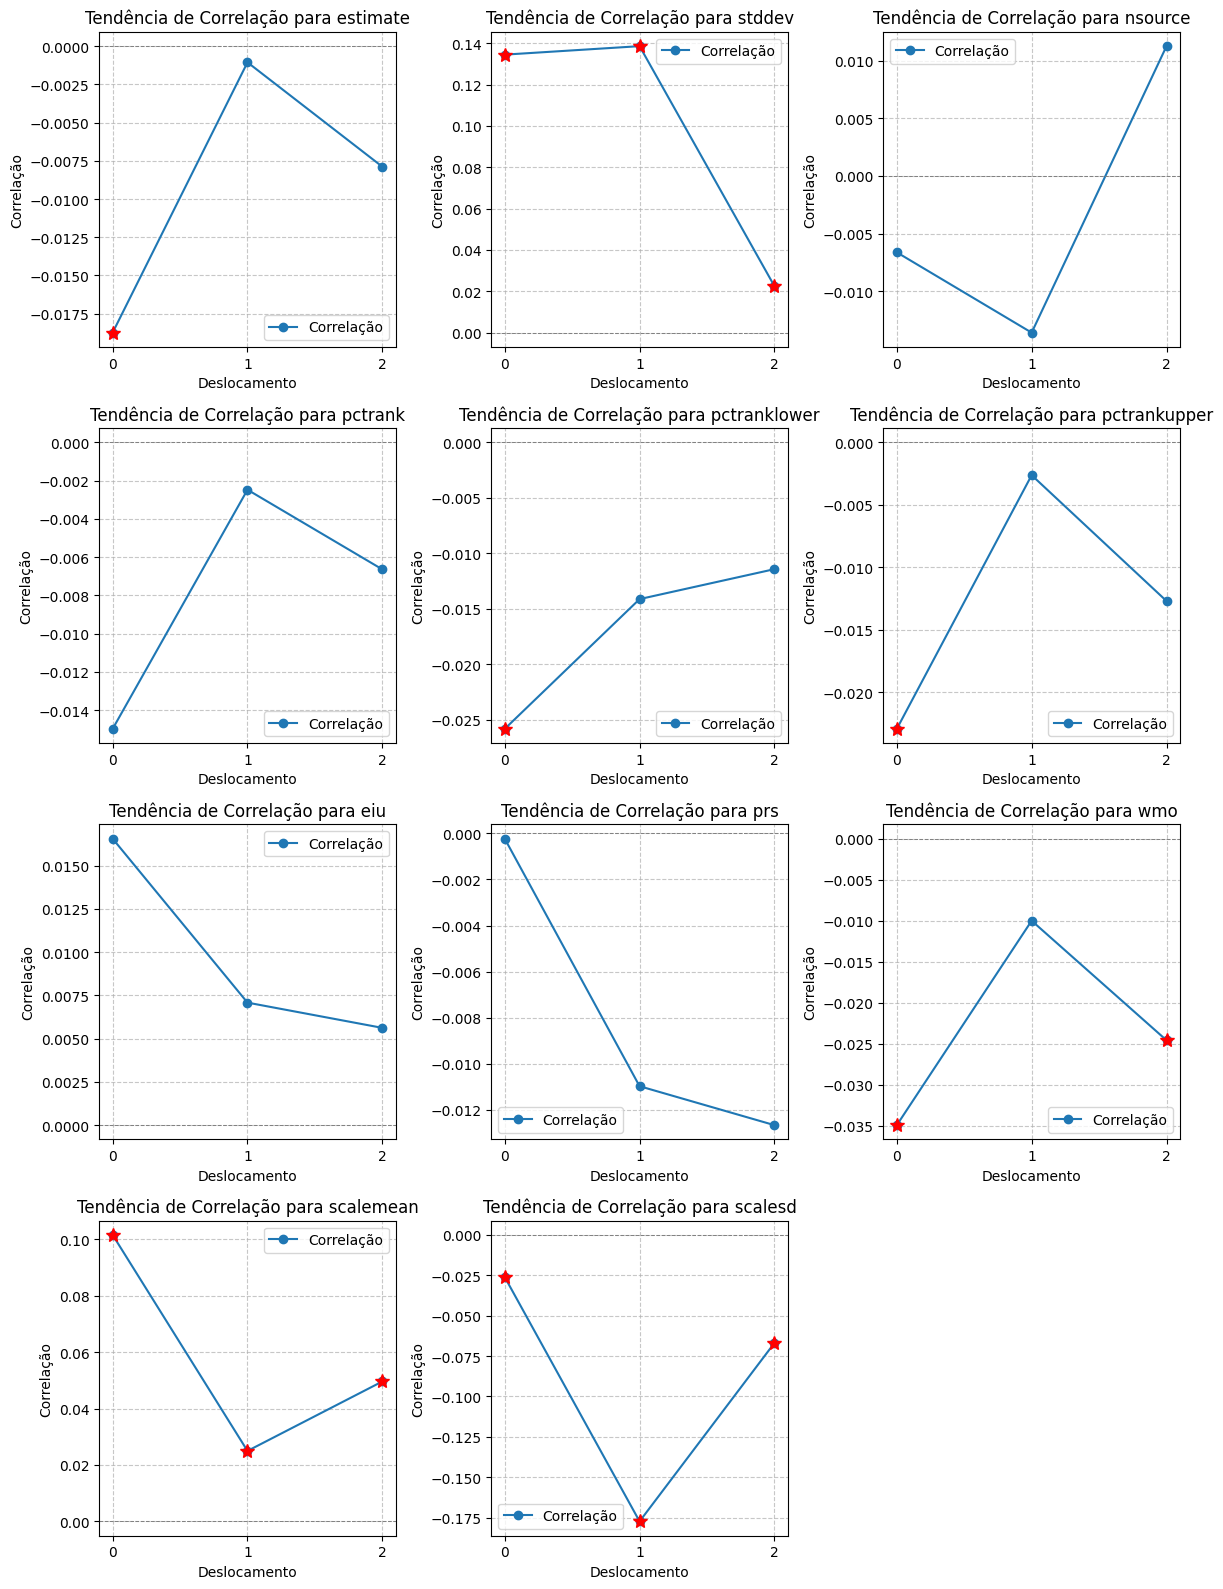

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# Selecionar colunas numéricas
numeric_cols = db.select_dtypes(include=np.number).columns

# Agrupar os dados
grouped = db.groupby(['indicator', 'code'], observed=False)

# Criar a variável 'extreme_event_code' com códigos numéricos
db['extreme_event_code'] = db['extreme_event']

# Laço para deslocar os valores de 'extreme_event_code' com diferentes shifts
correlations = []
for i in range(3):
    col_name = f'extreme_event_code_shifted_{i}'
    db[col_name] = grouped['extreme_event_code'].transform(lambda x: x.shift(i))
    db[col_name] = db[col_name].fillna(db['extreme_event_code'])
    for col in numeric_cols:
        estimate = db[col]
        extreme_event_code_shifted = db[col_name]
        correlation, p_value = spearmanr(estimate, extreme_event_code_shifted)
        correlations.append({'variable': col, 'correlation': correlation, 'shift': i, 'p_value': p_value})

# Remover colunas auxiliares
db = db.drop(columns=['extreme_event_code'] + [f'extreme_event_code_shifted_{i}' for i in range(3)])

# Criar DataFrame para a tabela de correlações
correlation_df = pd.DataFrame(correlations)

# Pivota a tabela para melhor visualização
correlation_pivot = correlation_df.pivot(index='variable', columns='shift', values=['correlation', 'p_value']).reset_index()
correlation_pivot = correlation_pivot.rename(columns={0: 'shift_0', 1: 'shift_1', 2: 'shift_2'})

# Adicionar coluna de conclusão do teste
correlation_pivot['Conclusão shift_0'] = np.where(correlation_pivot['p_value']['shift_0'] < 0.05, 'Significativo', 'Não Significativo')
correlation_pivot['Conclusão shift_1'] = np.where(correlation_pivot['p_value']['shift_1'] < 0.05, 'Significativo', 'Não Significativo')
correlation_pivot['Conclusão shift_2'] = np.where(correlation_pivot['p_value']['shift_2'] < 0.05, 'Significativo', 'Não Significativo')

# Converter para Markdown
markdown_table = correlation_pivot.to_markdown(index=False)
print(markdown_table)

import seaborn as sns
import matplotlib.pyplot as plt

# Transformar os dados para visualização em heatmap
heatmap_data = correlation_df.pivot_table(
    index='variable',
    columns='shift',
    values='correlation'
)

# Heatmap das correlações
plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_data, annot=True, cmap='coolwarm', fmt=".2f", cbar_kws={'label': 'Correlação'}
)
plt.title('Heatmap de Correlações entre Variáveis e Eventos Extremos Deslocados')
plt.ylabel('Variáveis')
plt.xlabel('Deslocamentos')
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
import math

num_vars = len(correlation_df['variable'].unique())
num_cols = 3
num_rows = math.ceil(num_vars / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 4 * num_rows))
axes = axes.flatten()

for i, var in enumerate(correlation_df['variable'].unique()):
    var_data = correlation_df[correlation_df['variable'] == var]
    ax = axes[i]
    ax.plot(var_data['shift'], var_data['correlation'], marker='o', label='Correlação')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    ax.set_title(f'Tendência de Correlação para {var}')
    ax.set_xlabel('Deslocamento')
    ax.set_ylabel('Correlação')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    ax.set_xticks([0,1,2])
    # Adicionando marcador para valores significativos
    for index, row in var_data.iterrows():
        if row['p_value'] < 0.05:
            ax.plot(row['shift'], row['correlation'], marker='*', markersize=10, color='red')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [4]:
import statsmodels.api as sm

# Definir variável dependente e independentes
y = db['estimate'].astype(np.float64)
X = db[['stddev', 'pctrank', 'eiu', 'prs', 'wmo', 'scalemean', 'scalesd']].astype(np.float64)
X = sm.add_constant(X)

Estimando regressões quantílicas...

Regressão para quantil: 0.1

Resultados antes da seleção de variáveis:
                         QuantReg Regression Results                          
Dep. Variable:               estimate   Pseudo R-squared:               0.4529
Model:                       QuantReg   Bandwidth:                     0.05853
Method:                 Least Squares   Sparsity:                        3.196
Date:                Thu, 19 Dec 2024   No. Observations:                13974
Time:                        15:27:35   Df Residuals:                    13966
                                        Df Model:                            7
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5155      0.008    -63.479      0.000      -0.531      -0.500
stddev         0.0392      0.009      4.150      0.000       0.021       0.058
pctrank        0.7573  

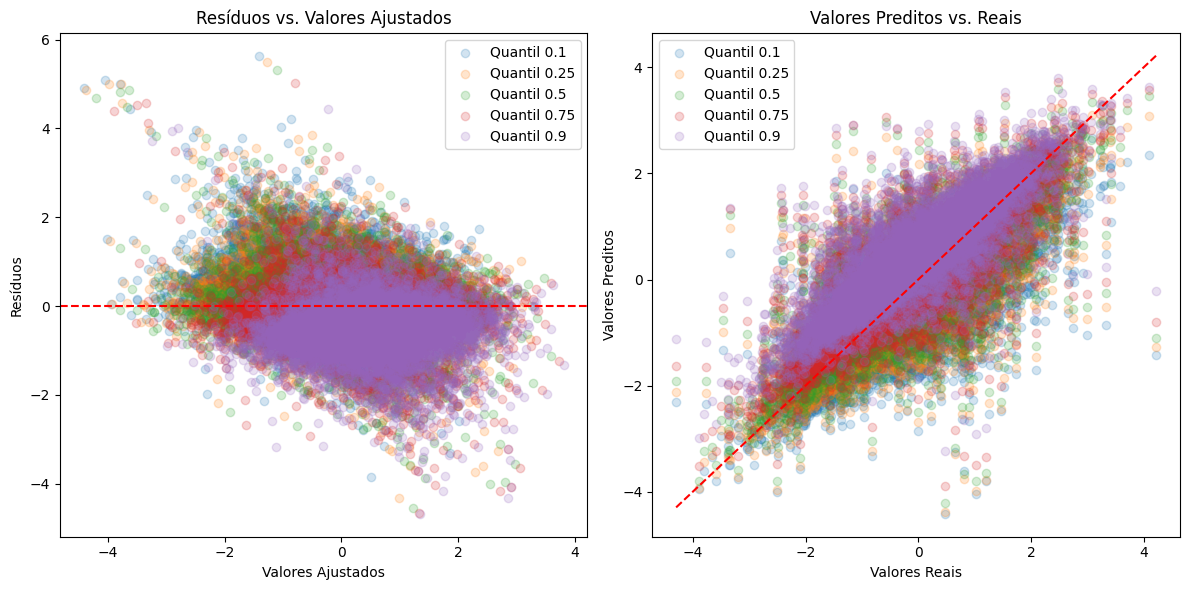

In [5]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import pandas as pd

# Estimar regressões quantílicas para 10%, 25%, 50%, 75%, 90%
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
results_before = {}
results_after = {}

print("Estimando regressões quantílicas...")
for q in quantiles:
    print(f"\nRegressão para quantil: {q}")
    model = sm.QuantReg(y, X)
    try:
        result_before = model.fit(q=q)
        results_before[q] = result_before
        print("\nResultados antes da seleção de variáveis:")
        print(result_before.summary())
        
        # Seleção recursiva de variáveis significativas
        X_selected = X.copy()
        while True:
            result_after = model.fit(q=q)
            p_values = result_after.pvalues
            significant_vars = p_values[p_values < 0.05].index
            if len(significant_vars) == len(X_selected.columns):
                break
            X_selected = X_selected[significant_vars]
            if len(X_selected.columns) == 0:
                break
            model = sm.QuantReg(y, X_selected)

        results_after[q] = result_after
        print("\nResultados após a seleção de variáveis:")
        print(result_after.summary())
        

    except Exception as e:
        print(f"Erro ao estimar a regressão para o quantil {q}: {e}")

# A seção de criação do DataFrame e seu print foram removidos pois o objetivo é gerar o sumário conforme o exemplo fornecido.
# Se necessário, essa parte pode ser reintroduzida com ajustes para gerar a saída desejada.


# Função para predição e análise de resíduos (mantida inalterada para fins de visualização)
def predicao_e_analise_residuos(model, X_np, y, X):
    plt.figure(figsize=(12, 6)) # Aumenta o tamanho da figura para acomodar dois subplots
    plt.subplot(1, 2, 1) # Cria o primeiro subplot (1 linha, 2 colunas, subplot 1)
    for q in quantiles:
        result = model.fit(q=q)
        predictions = result.predict(X_np)
        residuals = y - predictions # Corrigido: Calculando os resíduos corretamente
        plt.scatter(predictions, residuals, alpha=0.2, label=f'Quantil {q}') # reduz a opacidade dos pontos
    plt.axhline(0, color='red', linestyle='--')
    plt.title("Resíduos vs. Valores Ajustados")
    plt.xlabel("Valores Ajustados")
    plt.ylabel("Resíduos")
    plt.legend()

    # Função para plotar valores preditos vs reais
    plt.subplot(1, 2, 2) # Cria o segundo subplot (1 linha, 2 colunas, subplot 2)
    for q in quantiles:
        result = model.fit(q=q)
        predictions = result.predict(X_np)
        plt.scatter(y, predictions, alpha=0.2, label=f'Quantil {q}') # Corrigido: Plotando y vs predictions
    #plt.plot([y.mX(), y.mX()], [y.mX(), y.mX()], 'r--') #Removido pois y.mX() não existe
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') #Adicionado linha para melhor visualização
    plt.title("Valores Preditos vs. Reais")
    plt.xlabel("Valores Reais")
    plt.ylabel("Valores Preditos")
    plt.legend()
    plt.tight_layout() # Ajusta o layout para evitar sobreposição
    plt.show()


# Executar a função de predição e análise de resíduos
predicao_e_analise_residuos(sm.QuantReg(y, X), X.values, y, X) # Corrigido: Passando X.values para evitar erro


# Regressão quantílica clássica - pressupostos

* Linearidade
* Independência dos erros
* Homoscedasticidade
* Ausência de multicolinearidade
* Caracterização de toda a distribuição condicional
* Robustez à outlier

# Regressão quantílica bootstrap - pressupostos

O bootstrap, de forma geral, é um procedimento não-paramétrico de reamostragem que impõe poucos pressupostos estatísticos sobre a distribuição dos erros ou da variável resposta. Abaixo segue uma análise ponto a ponto dos itens mencionados:

1. **Linearidade:**  
   O bootstrap não assume linearidade entre as variáveis independentes e a variável dependente. Ele pode ser aplicado independentemente de a relação ser linear ou não.  
   *Não é um pressuposto obrigatório.*

2. **Independência dos erros:**  
   Este é um ponto importante. Em muitos casos, assume-se que as observações são independentes e identicamente distribuídas (i.i.d.). O bootstrap clássico espera que a amostra original seja representativa da população e que o processo de amostragem preserve a independência entre as observações. Caso haja dependência (por exemplo, em dados de séries temporais ou dados espaciais), técnicas de bootstrap modificadas (como block bootstrap) devem ser utilizadas.  
   *Independência das observações é um pressuposto importante para o bootstrap padrão.*

3. **Homoscedasticidade:**  
   O bootstrap não requer homoscedasticidade (variância constante dos erros). Ele não depende de suposições sobre a forma da distribuição dos resíduos. O bootstrap simplesmente reamostra dados empiricamente para inferir sobre a variabilidade dos estimadores.  
   *Não é um pressuposto obrigatório.*

4. **Ausência de multicolinearidade:**  
   A multicolinearidade não impede o uso do bootstrap. No entanto, se o modelo sofrer com alta multicolinearidade, os coeficientes poderão ser instáveis. O bootstrap irá apenas refletir isso nas estimativas e em seus intervalos de confiança, mas não resolve o problema em si.  
   *Não é um pressuposto para o método, mas multicolinearidade continua sendo um problema de modelagem.*

5. **Caracterização de toda a distribuição condicional:**  
   O bootstrap não exige conhecer a distribuição condicional completa. É justamente uma vantagem do bootstrap: ele evita suposições paramétricas fortes ao usar a própria amostra para inferir a variabilidade.  
   *Não é um pressuposto obrigatório.*

6. **Robustez a outliers:**  
   O bootstrap não garante por si só robustez contra outliers. Ele vai reamostrar o que estiver na base de dados. Se existirem outliers, eles continuarão aparecendo nas reamostragens, potencialmente afetando a estimação. A robustez a outliers dependerá do modelo (por exemplo, o uso de métodos robustos, como a regressão quantílica, já oferece alguma robustez). O bootstrap em si não exige pressuposto de ausência de outliers nem é por si só robusto a eles.  
   *Não é um pressuposto obrigatório.*

**Em resumo:**  
O principal pressuposto para a validade do bootstrap simples é que as observações sejam representativas da população-alvo e que sejam independentes (ou adequadamente tratadas se não o forem). O bootstrap não exige linearidade, homoscedasticidade, ausência de multicolinearidade, conhecimento prévio da distribuição condicional completa ou robustez a outliers.

Estimando regressões quantílicas...

Regressão para quantil: 0.1

Resultados antes da seleção de variáveis:
                         QuantReg Regression Results                          
Dep. Variable:               estimate   Pseudo R-squared:               0.4529
Model:                       QuantReg   Bandwidth:                     0.05853
Method:                 Least Squares   Sparsity:                        3.196
Date:                Thu, 19 Dec 2024   No. Observations:                13974
Time:                        15:27:42   Df Residuals:                    13966
                                        Df Model:                            7
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5155      0.008    -63.479      0.000      -0.531      -0.500
stddev         0.0392      0.009      4.150      0.000       0.021       0.058
pctrank        0.7573  

/home/pcbrom/myenv/lib/python3.12/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +



Pseudo R-squared com (IC 95% bootstrap): 0.4384 com [0.4066, 0.4647]

Coeficientes com IC 95% Bootstrap:
const 	 -0.5143 	 IC 95%: [-0.5354, -0.4973]
stddev 	 0.0341 	 IC 95%: [0.0210, 0.0518]
pctrank 	 0.7569 	 IC 95%: [0.7393, 0.7789]
eiu 	 0.0840 	 IC 95%: [0.0673, 0.0992]
prs 	 0.0591 	 IC 95%: [0.0419, 0.0732]
wmo 	 0.0828 	 IC 95%: [0.0689, 0.1000]

Regressão para quantil: 0.25

Resultados antes da seleção de variáveis:
                         QuantReg Regression Results                          
Dep. Variable:               estimate   Pseudo R-squared:               0.5360
Model:                       QuantReg   Bandwidth:                     0.05750
Method:                 Least Squares   Sparsity:                        1.145
Date:                Thu, 19 Dec 2024   No. Observations:                13974
Time:                        15:28:05   Df Residuals:                    13966
                                        Df Model:                            7
                

/home/pcbrom/myenv/lib/python3.12/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/pcbrom/myenv/lib/python3.12/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/home/pcbrom/myenv/lib/python3.12/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +



Pseudo R-squared com (IC 95% bootstrap): 0.4369 com [0.4088, 0.4659]

Coeficientes com IC 95% Bootstrap:
const 	 0.5169 	 IC 95%: [0.4961, 0.5365]
pctrank 	 0.7600 	 IC 95%: [0.7391, 0.7799]
eiu 	 0.0853 	 IC 95%: [0.0690, 0.1027]
prs 	 0.0552 	 IC 95%: [0.0370, 0.0731]
wmo 	 0.0840 	 IC 95%: [0.0666, 0.1008]
scalemean 	 -0.0443 	 IC 95%: [-0.0636, -0.0301]


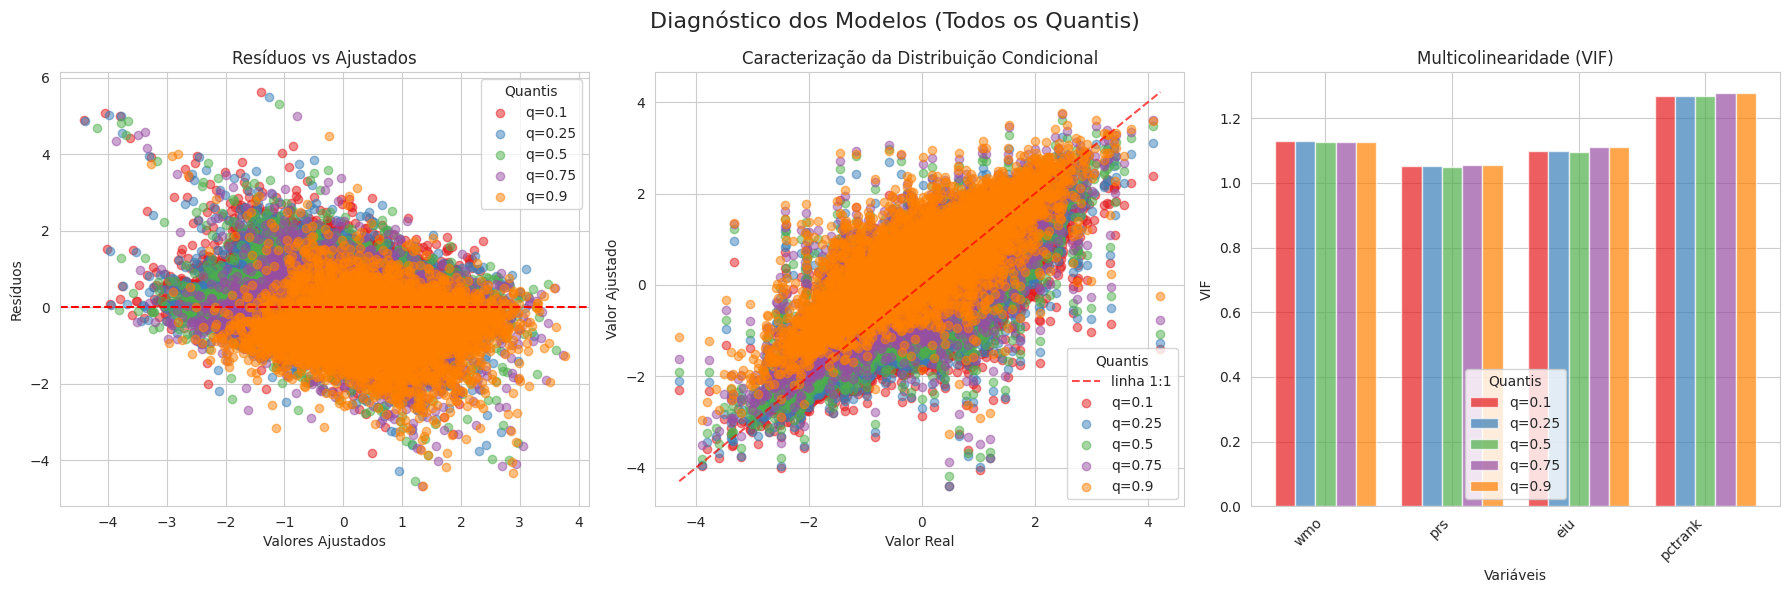

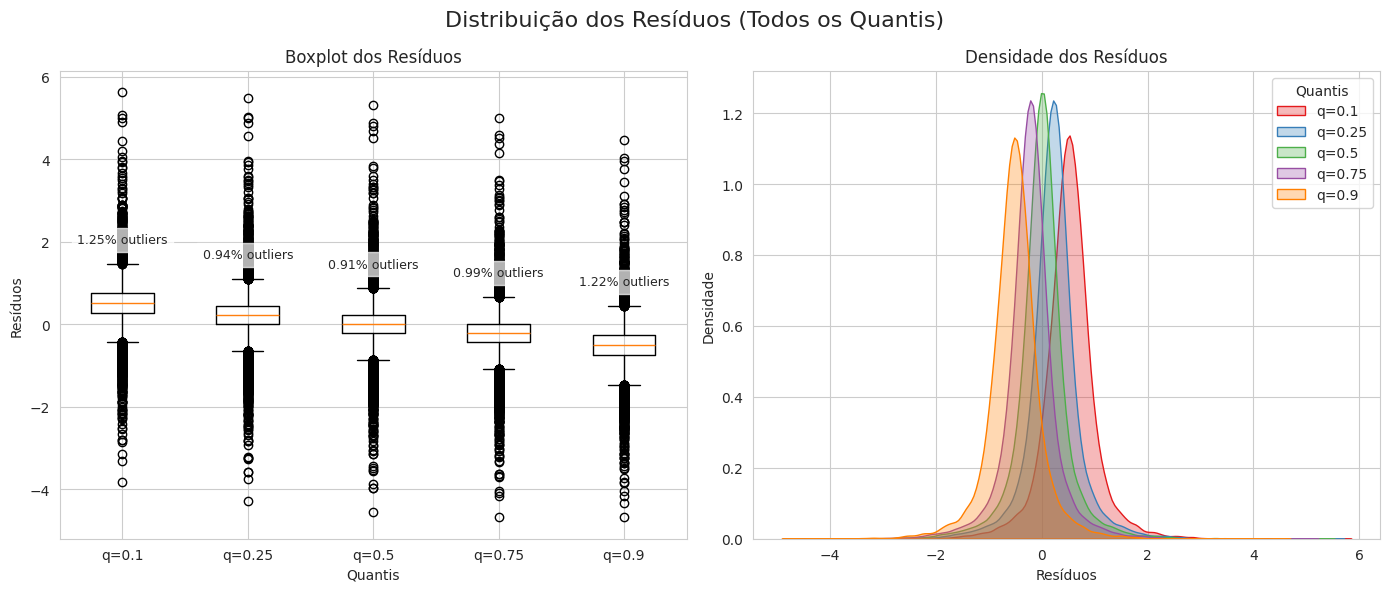

In [6]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
import seaborn as sns

sns.set_style("whitegrid")  # Estilo estético
cmap = sns.color_palette("Set1", n_colors=5)  # Paleta de cores

# Função para seleção recursiva de variáveis significativas
def select_significant_vars(model, y, X, quantile, significance_level=0.05):
    X_selected = X.copy()
    while True:
        result = model.fit(q=quantile)
        p_values = result.pvalues
        significant_vars = p_values[p_values < significance_level].index
        if len(significant_vars) == len(X_selected.columns):
            break
        if len(significant_vars) == 0:
            break
        X_selected = X_selected[significant_vars]
        model = sm.QuantReg(y, X_selected)
    return result, X_selected

# Função para realizar o bootstrap
def perform_bootstrap(q, X_final, y, n_bootstrap):
    def fit_bootstrap(idx):
        X_boot = X_final.iloc[idx]
        y_boot = y.iloc[idx]
        model_boot = sm.QuantReg(y_boot, X_boot)
        try:
            result_boot = model_boot.fit(q=q)
            pseudo_r2 = 1 - (result_boot.ssr / np.sum((y_boot.values - np.median(y_boot.values))**2))
            return result_boot.params.values, pseudo_r2
        except:
            return np.full(X_final.shape[1], np.nan), np.nan

    boot_results = Parallel(n_jobs=-1)(
        delayed(fit_bootstrap)(np.random.choice(len(y), len(y), replace=True)) for _ in range(n_bootstrap)
    )
    boot_coefs = np.array([res[0] for res in boot_results if not np.isnan(res[0]).any()])
    boot_pseudo_r2 = np.array([res[1] for res in boot_results if not np.isnan(res[1])])
    return boot_coefs, boot_pseudo_r2

# Função para computar estatísticas de diagnóstico
def compute_diagnostics(result, X_final, y):
    fitted = result.predict(X_final)
    residuals = y - fitted
    dw_stat = durbin_watson(residuals)

    # VIF
    if 'const' not in X_final.columns:
        X_vif = sm.add_constant(X_final)
    else:
        X_vif = X_final.copy()
    vif_values = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

    return {
        'fitted': fitted,
        'residuals': residuals,
        'dw': dw_stat,
        'vif': vif_values,
        'vif_vars': X_vif.columns
    }

#####################################
# Aqui começa o fluxo principal
#####################################

# Suponha que X e y já estejam definidos no contexto
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
results_before = {}
results_after = {}
boot_results_dict = {}
diagnostics_dict = {}
n_bootstrap = 1000  # Número de reamostragens

print("Estimando regressões quantílicas...")
# Tentar ajustar para cada quantil, se falhar, continua com os demais
valid_quantiles = []  # Guardar apenas os quantis que funcionaram
for q in quantiles:
    print(f"\nRegressão para quantil: {q}")
    model = sm.QuantReg(y, X)
    try:
        # Regressão antes da seleção de variáveis
        result_before = model.fit(q=q)
        results_before[q] = result_before
        print("\nResultados antes da seleção de variáveis:")
        print(result_before.summary())

        # Seleção recursiva de variáveis significativas
        result_after, X_final = select_significant_vars(model, y, X, q)
        results_after[q] = {'result': result_after, 'X_final': X_final}
        print("\nResultados após a seleção de variáveis:")
        print(result_after.summary())

        # Bootstrap para o modelo final
        boot_coefs, boot_pseudo_r2 = perform_bootstrap(q, X_final, y, n_bootstrap)
        boot_results_dict[q] = {'coefs': boot_coefs, 'pseudo_r2': boot_pseudo_r2}

        # Análise bootstrap
        pseudo_r2_initial = 1 - (result_after.ssr / np.sum((y.values - np.median(y.values))**2))
        pseudo_r2_ci = np.percentile(boot_pseudo_r2, [2.5, 97.5])
        print(f"\nPseudo R-squared com (IC 95% bootstrap): {pseudo_r2_initial:.4f} com [{pseudo_r2_ci[0]:.4f}, {pseudo_r2_ci[1]:.4f}]")

        # Calcular IC para coeficientes
        coef_ci = np.percentile(boot_coefs, [2.5, 97.5], axis=0)
        print("\nCoeficientes com IC 95% Bootstrap:")
        for i, coef in enumerate(result_after.params):
            print(f"{X_final.columns[i]} \t {coef:.4f} \t IC 95%: [{coef_ci[0,i]:.4f}, {coef_ci[1,i]:.4f}]")

        # Calcular diagnósticos
        diags = compute_diagnostics(result_after, X_final, y)
        diags['variables'] = X_final.columns
        diagnostics_dict[q] = diags
        valid_quantiles.append(q)

    except Exception as e:
        print(f"Erro ao estimar a regressão para o quantil {q}: {e}")

if not valid_quantiles:
    print("Nenhum quantil pôde ser estimado com sucesso.")
    raise SystemExit

# Figura de diagnóstico geral (todos os quantis juntos)
fig, axes = plt.subplots(1, 3, figsize=(18,6))
fig.suptitle("Diagnóstico dos Modelos (Todos os Quantis)", fontsize=16)

# 1) Resíduos vs Ajustados
ax = axes[0]
for i, q in enumerate(valid_quantiles):
    fitted = diagnostics_dict[q]['fitted']
    residuals = diagnostics_dict[q]['residuals']
    ax.scatter(fitted, residuals, alpha=0.5, label=f'q={q}', color=cmap[i])
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel("Valores Ajustados")
ax.set_ylabel("Resíduos")
ax.set_title("Resíduos vs Ajustados")
ax.grid(True)
ax.legend(title='Quantis', loc='best')

# 2) Caracterização da Distribuição Condicional (Y vs Ajustados)
ax = axes[1]
y_min, y_max = y.min(), y.max()
ax.plot([y_min, y_max], [y_min, y_max], 'r--', label='linha 1:1', alpha=0.7)
for i, q in enumerate(valid_quantiles):
    fitted = diagnostics_dict[q]['fitted']
    ax.scatter(y, fitted, alpha=0.5, label=f'q={q}', color=cmap[i])
ax.set_xlabel("Valor Real")
ax.set_ylabel("Valor Ajustado")
ax.set_title("Caracterização da Distribuição Condicional")
ax.grid(True)
ax.legend(title='Quantis', loc='best')

# 3) VIF (apenas se houver variáveis comuns)
ax = axes[2]
all_vars_sets = [set(diagnostics_dict[q]['variables']) for q in valid_quantiles]
common_vars = set.intersection(*all_vars_sets)

if len(common_vars) == 0:
    ax.text(0.5, 0.5, 'Não há variáveis comuns entre todos os quantis', 
            ha='center', va='center', fontsize=12)
    ax.set_axis_off()
else:
    common_vars = list(common_vars)
    vif_df = pd.DataFrame(index=common_vars, columns=valid_quantiles)
    for q in valid_quantiles:
        vars_q = diagnostics_dict[q]['variables']
        vif_q = diagnostics_dict[q]['vif']
        vif_series = pd.Series(vif_q, index=diagnostics_dict[q]['vif_vars'])
        vif_df[q] = vif_series[common_vars]

    vif_df = vif_df.astype(float)
    X_axis = np.arange(len(common_vars))
    bar_width = 0.8 / len(valid_quantiles)  # Ajuste de largura para todas as barras caberem
    for i, q in enumerate(valid_quantiles):
        ax.bar(X_axis + i*bar_width, vif_df[q], bar_width, label=f'q={q}', 
               alpha=0.7, color=cmap[i])
    ax.set_xticks(X_axis + bar_width*(len(valid_quantiles)-1)/2)
    ax.set_xticklabels(common_vars, rotation=45, ha='right')
    ax.set_xlabel("Variáveis")
    ax.set_ylabel("VIF")
    ax.set_title("Multicolinearidade (VIF)")
    ax.legend(title='Quantis', loc='best')
    ax.grid(True)

plt.tight_layout()
plt.show()

# Nova figura para parear Boxplot e Densidade dos resíduos
fig, (ax_box, ax_density) = plt.subplots(1, 2, figsize=(14,6))
fig.suptitle("Distribuição dos Resíduos (Todos os Quantis)", fontsize=16)

res_list = [diagnostics_dict[q]['residuals'] for q in valid_quantiles]

# Boxplot com quantis
bp = ax_box.boxplot(res_list, tick_labels=[f'q={q}' for q in valid_quantiles])
ax_box.set_title("Boxplot dos Resíduos")
ax_box.set_xlabel("Quantis")
ax_box.set_ylabel("Resíduos")
ax_box.grid(True)

# Calcular e exibir percentual de outliers fora de [-3,3]
for i, q in enumerate(valid_quantiles):
    res = diagnostics_dict[q]['residuals']
    outliers_pct = np.mean((res < -2) | (res > 2)) * 100
    # Pegar posição do topo do box (top whisker)
    top_whisker_y = bp['whiskers'][2*i+1].get_ydata()[1]
    ax_box.text(i+1, top_whisker_y+0.5, f'{outliers_pct:.2f}% outliers', ha='center', fontsize=9, 
            bbox=dict(facecolor='white', alpha=0.7))

# Gráfico de densidade (KDE) dos resíduos para cada quantil
for i, q in enumerate(valid_quantiles):
    res = diagnostics_dict[q]['residuals']
    sns.kdeplot(res, ax=ax_density, label=f'q={q}', color=cmap[i], fill=True, alpha=0.3)

ax_density.set_title("Densidade dos Resíduos")
ax_density.set_xlabel("Resíduos")
ax_density.set_ylabel("Densidade")
ax_density.grid(True)
ax_density.legend(title="Quantis", loc='best')

plt.tight_layout()
plt.show()


Estimando regressões quantílicas...

Regressão para quantil: 0.1

Resultados antes da seleção de variáveis:
                         QuantReg Regression Results                          
Dep. Variable:               estimate   Pseudo R-squared:               0.4529
Model:                       QuantReg   Bandwidth:                     0.05853
Method:                 Least Squares   Sparsity:                        3.196
Date:                Thu, 19 Dec 2024   No. Observations:                13974
Time:                        15:29:22   Df Residuals:                    13966
                                        Df Model:                            7
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5155      0.008    -63.479      0.000      -0.531      -0.500
stddev         0.0392      0.009      4.150      0.000       0.021       0.058
pctrank        0.7573  

/home/pcbrom/myenv/lib/python3.12/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +



Pseudo R-squared com (IC 95% bootstrap): 0.4384 com [0.4082, 0.4640]

Coeficientes com IC 95% Bootstrap:
const 	 -0.5143 	 IC 95%: [-0.5363, -0.4968]
stddev 	 0.0341 	 IC 95%: [0.0198, 0.0524]
pctrank 	 0.7569 	 IC 95%: [0.7391, 0.7771]
eiu 	 0.0840 	 IC 95%: [0.0688, 0.0992]
prs 	 0.0591 	 IC 95%: [0.0417, 0.0736]
wmo 	 0.0828 	 IC 95%: [0.0686, 0.1023]

Regressão para quantil: 0.25

Resultados antes da seleção de variáveis:
                         QuantReg Regression Results                          
Dep. Variable:               estimate   Pseudo R-squared:               0.5360
Model:                       QuantReg   Bandwidth:                     0.05750
Method:                 Least Squares   Sparsity:                        1.145
Date:                Thu, 19 Dec 2024   No. Observations:                13974
Time:                        15:29:44   Df Residuals:                    13966
                                        Df Model:                            7
                

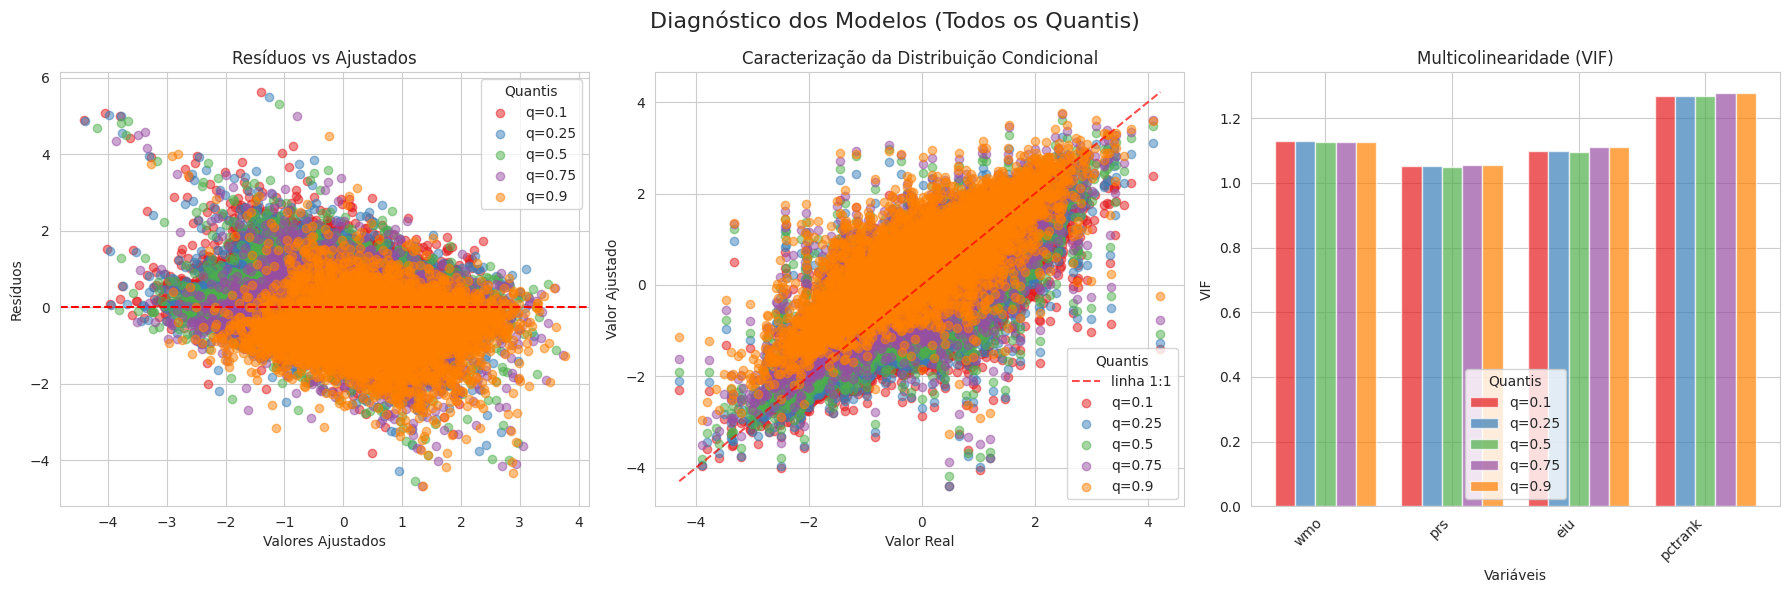

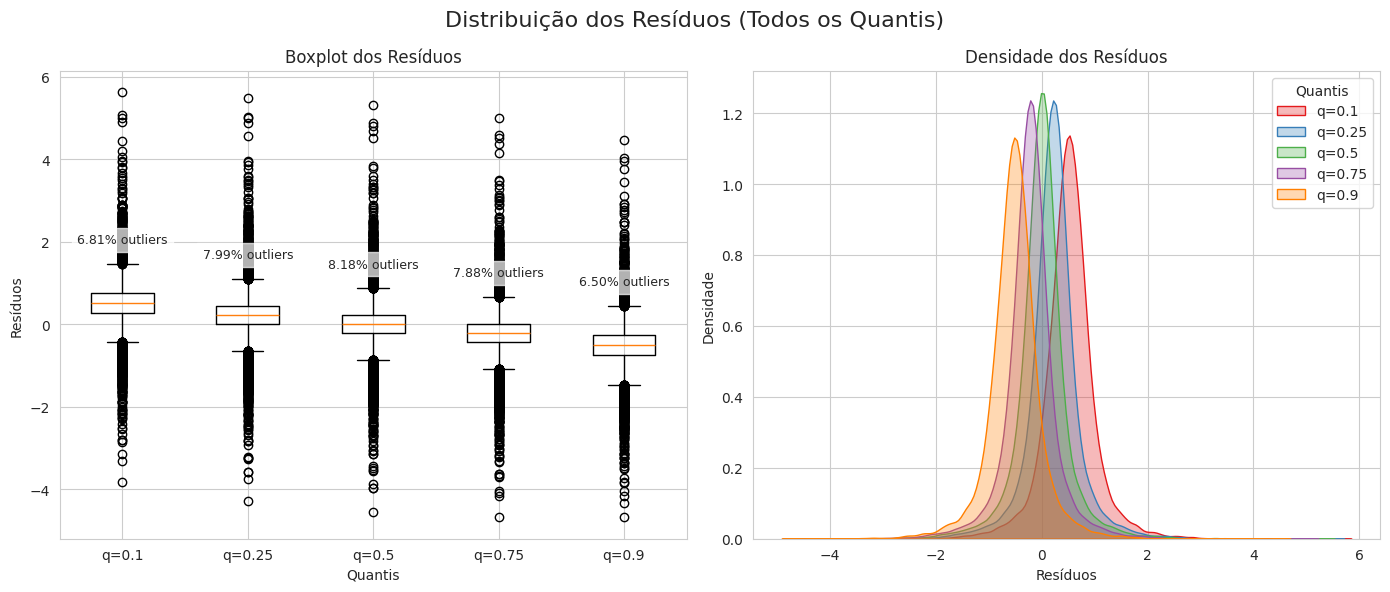

In [7]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
import seaborn as sns

sns.set_style("whitegrid")  # Estilo estético
cmap = sns.color_palette("Set1", n_colors=5)  # Paleta de cores

# Função para seleção recursiva de variáveis significativas
def select_significant_vars(model, y, X, quantile, significance_level=0.05):
    X_selected = X.copy()
    while True:
        result = model.fit(q=quantile)
        p_values = result.pvalues
        significant_vars = p_values[p_values < significance_level].index
        if len(significant_vars) == len(X_selected.columns):
            break
        if len(significant_vars) == 0:
            break
        X_selected = X_selected[significant_vars]
        model = sm.QuantReg(y, X_selected)
    return result, X_selected

# Função para realizar o bootstrap
def perform_bootstrap(q, X_final, y, n_bootstrap):
    def fit_bootstrap(idx):
        X_boot = X_final.iloc[idx]
        y_boot = y.iloc[idx]
        model_boot = sm.QuantReg(y_boot, X_boot)
        try:
            result_boot = model_boot.fit(q=q)
            pseudo_r2 = 1 - (result_boot.ssr / np.sum((y_boot.values - np.median(y_boot.values))**2))
            return result_boot.params.values, pseudo_r2
        except:
            return np.full(X_final.shape[1], np.nan), np.nan

    boot_results = Parallel(n_jobs=-1)(
        delayed(fit_bootstrap)(np.random.choice(len(y), len(y), replace=True)) for _ in range(n_bootstrap)
    )
    boot_coefs = np.array([res[0] for res in boot_results if not np.isnan(res[0]).any()])
    boot_pseudo_r2 = np.array([res[1] for res in boot_results if not np.isnan(res[1])])
    return boot_coefs, boot_pseudo_r2

# Função para computar estatísticas de diagnóstico
def compute_diagnostics(result, X_final, y):
    fitted = result.predict(X_final)
    residuals = y - fitted
    dw_stat = durbin_watson(residuals)

    # VIF
    if 'const' not in X_final.columns:
        X_vif = sm.add_constant(X_final)
    else:
        X_vif = X_final.copy()
    vif_values = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

    return {
        'fitted': fitted,
        'residuals': residuals,
        'dw': dw_stat,
        'vif': vif_values,
        'vif_vars': X_vif.columns
    }

#####################################
# Aqui começa o fluxo principal
#####################################

# Suponha que X e y já estejam definidos no contexto
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
results_before = {}
results_after = {}
boot_results_dict = {}
diagnostics_dict = {}
n_bootstrap = 1000  # Número de reamostragens

print("Estimando regressões quantílicas...")
# Tentar ajustar para cada quantil, se falhar, continua com os demais
valid_quantiles = []  # Guardar apenas os quantis que funcionaram
for q in quantiles:
    print(f"\nRegressão para quantil: {q}")
    model = sm.QuantReg(y, X)
    try:
        # Regressão antes da seleção de variáveis
        result_before = model.fit(q=q)
        results_before[q] = result_before
        print("\nResultados antes da seleção de variáveis:")
        print(result_before.summary())

        # Seleção recursiva de variáveis significativas
        result_after, X_final = select_significant_vars(model, y, X, q)
        results_after[q] = {'result': result_after, 'X_final': X_final}
        print("\nResultados após a seleção de variáveis:")
        print(result_after.summary())

        # Bootstrap para o modelo final
        boot_coefs, boot_pseudo_r2 = perform_bootstrap(q, X_final, y, n_bootstrap)
        boot_results_dict[q] = {'coefs': boot_coefs, 'pseudo_r2': boot_pseudo_r2}

        # Análise bootstrap
        pseudo_r2_initial = 1 - (result_after.ssr / np.sum((y.values - np.median(y.values))**2))
        pseudo_r2_ci = np.percentile(boot_pseudo_r2, [2.5, 97.5])
        print(f"\nPseudo R-squared com (IC 95% bootstrap): {pseudo_r2_initial:.4f} com [{pseudo_r2_ci[0]:.4f}, {pseudo_r2_ci[1]:.4f}]")

        # Calcular IC para coeficientes
        coef_ci = np.percentile(boot_coefs, [2.5, 97.5], axis=0)
        print("\nCoeficientes com IC 95% Bootstrap:")
        for i, coef in enumerate(result_after.params):
            print(f"{X_final.columns[i]} \t {coef:.4f} \t IC 95%: [{coef_ci[0,i]:.4f}, {coef_ci[1,i]:.4f}]")

        # Calcular diagnósticos
        diags = compute_diagnostics(result_after, X_final, y)
        diags['variables'] = X_final.columns
        diagnostics_dict[q] = diags
        valid_quantiles.append(q)

    except Exception as e:
        print(f"Erro ao estimar a regressão para o quantil {q}: {e}")

if not valid_quantiles:
    print("Nenhum quantil pôde ser estimado com sucesso.")
    raise SystemExit

# Figura de diagnóstico geral (todos os quantis juntos)
fig, axes = plt.subplots(1, 3, figsize=(18,6))
fig.suptitle("Diagnóstico dos Modelos (Todos os Quantis)", fontsize=16)

# 1) Resíduos vs Ajustados
ax = axes[0]
for i, q in enumerate(valid_quantiles):
    fitted = diagnostics_dict[q]['fitted']
    residuals = diagnostics_dict[q]['residuals']
    ax.scatter(fitted, residuals, alpha=0.5, label=f'q={q}', color=cmap[i])
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel("Valores Ajustados")
ax.set_ylabel("Resíduos")
ax.set_title("Resíduos vs Ajustados")
ax.grid(True)
ax.legend(title='Quantis', loc='best')

# 2) Caracterização da Distribuição Condicional (Y vs Ajustados)
ax = axes[1]
y_min, y_max = y.min(), y.max()
ax.plot([y_min, y_max], [y_min, y_max], 'r--', label='linha 1:1', alpha=0.7)
for i, q in enumerate(valid_quantiles):
    fitted = diagnostics_dict[q]['fitted']
    ax.scatter(y, fitted, alpha=0.5, label=f'q={q}', color=cmap[i])
ax.set_xlabel("Valor Real")
ax.set_ylabel("Valor Ajustado")
ax.set_title("Caracterização da Distribuição Condicional")
ax.grid(True)
ax.legend(title='Quantis', loc='best')

# 3) VIF (apenas se houver variáveis comuns)
ax = axes[2]
all_vars_sets = [set(diagnostics_dict[q]['variables']) for q in valid_quantiles]
common_vars = set.intersection(*all_vars_sets)

if len(common_vars) == 0:
    ax.text(0.5, 0.5, 'Não há variáveis comuns entre todos os quantis', 
            ha='center', va='center', fontsize=12)
    ax.set_axis_off()
else:
    common_vars = list(common_vars)
    vif_df = pd.DataFrame(index=common_vars, columns=valid_quantiles)
    for q in valid_quantiles:
        vars_q = diagnostics_dict[q]['variables']
        vif_q = diagnostics_dict[q]['vif']
        vif_series = pd.Series(vif_q, index=diagnostics_dict[q]['vif_vars'])
        vif_df[q] = vif_series[common_vars]

    vif_df = vif_df.astype(float)
    X_axis = np.arange(len(common_vars))
    bar_width = 0.8 / len(valid_quantiles)  # Ajuste de largura para todas as barras caberem
    for i, q in enumerate(valid_quantiles):
        ax.bar(X_axis + i*bar_width, vif_df[q], bar_width, label=f'q={q}', 
               alpha=0.7, color=cmap[i])
    ax.set_xticks(X_axis + bar_width*(len(valid_quantiles)-1)/2)
    ax.set_xticklabels(common_vars, rotation=45, ha='right')
    ax.set_xlabel("Variáveis")
    ax.set_ylabel("VIF")
    ax.set_title("Multicolinearidade (VIF)")
    ax.legend(title='Quantis', loc='best')
    ax.grid(True)

plt.tight_layout()
plt.show()

# Nova figura para parear Boxplot e Densidade dos resíduos
fig, (ax_box, ax_density) = plt.subplots(1, 2, figsize=(14,6))
fig.suptitle("Distribuição dos Resíduos (Todos os Quantis)", fontsize=16)

res_list = [diagnostics_dict[q]['residuals'] for q in valid_quantiles]

# Boxplot com quantis
bp = ax_box.boxplot(res_list, tick_labels=[f'q={q}' for q in valid_quantiles])
ax_box.set_title("Boxplot dos Resíduos")
ax_box.set_xlabel("Quantis")
ax_box.set_ylabel("Resíduos")
ax_box.grid(True)

# Calcular e exibir percentual de outliers fora de [-3,3]
for i, q in enumerate(valid_quantiles):
    res = diagnostics_dict[q]['residuals']
    # obter os limites superior e inferior do boxplot
    upper_whisker = bp['whiskers'][2*i+1].get_ydata()[1]
    lower_whisker = bp['whiskers'][2*i].get_ydata()[1]
    outliers_pct = np.mean((res < lower_whisker) | (res > upper_whisker)) * 100
    # Pegar posição do topo do box (top whisker)
    
    ax_box.text(i+1, upper_whisker+0.5, f'{outliers_pct:.2f}% outliers', ha='center', fontsize=9, 
            bbox=dict(facecolor='white', alpha=0.7))

# Gráfico de densidade (KDE) dos resíduos para cada quantil
for i, q in enumerate(valid_quantiles):
    res = diagnostics_dict[q]['residuals']
    sns.kdeplot(res, ax=ax_density, label=f'q={q}', color=cmap[i], fill=True, alpha=0.3)

ax_density.set_title("Densidade dos Resíduos")
ax_density.set_xlabel("Resíduos")
ax_density.set_ylabel("Densidade")
ax_density.grid(True)
ax_density.legend(title="Quantis", loc='best')

plt.tight_layout()
plt.show()
